[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lalvim/DataMining/blob/main/notebooks/unidade_05/05_02_knn.ipynb)

# Unidade V — Classificação e Regressão

## k-vizinhos mais próximos (k-NN)

**Carga estimada:** 1,5 hora  
**Pré-requisitos:** classificação, distância Euclidiana e padronização.

> **Pergunta norteadora:** como classificar um novo objeto a partir dos exemplos mais próximos?

Este notebook apresenta a intuição, aplicação e limitações do k-NN na mineração de dados.

## Objetivos de aprendizagem

- explicar o k-NN como votação entre exemplos próximos;
- calcular e interpretar distâncias;
- demonstrar por que a escala altera a vizinhança;
- relacionar $k$ à sensibilidade e à suavização;
- distinguir visualmente sobreajuste e subajuste ao variar $k$;
- reconhecer custos e efeitos de atributos irrelevantes;
- justificar representação, distância e validação.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

## 1. k-NN: decidir por analogia local

No método dos $k$ vizinhos mais próximos (*k-nearest neighbors*, k-NN), um novo objeto é comparado aos exemplos armazenados:

1. calcular a distância entre o novo objeto e cada exemplo;
2. selecionar os $k$ menores valores;
3. realizar uma votação entre as classes desses vizinhos;
4. atribuir a classe majoritária.

Para atributos numéricos, uma escolha comum é a distância Euclidiana:

$$
d(\mathbf{x},\mathbf{z})
=
\sqrt{\sum_{j=1}^{p}(x_j-z_j)^2}.
$$

A proximidade não existe “por si só”: ela depende dos atributos, da escala e da função de distância escolhida.

## 2. Escala pode mudar quem é considerado vizinho

Considere seis clientes descritos por tempo como cliente, em meses, e número de chamados. O novo cliente possui 35 meses e quatro chamados.

O tempo varia por dezenas; os chamados variam de 0 a 5. Sem padronização, um mês de diferença e um chamado de diferença entram numericamente com o mesmo peso, de modo que a amplitude do tempo tende a dominar a distância.

In [2]:
clientes_treino = pd.DataFrame({
    "cliente": list("ABCDEF"),
    "tempo_meses": [5, 10, 20, 30, 40, 50],
    "chamados": [4, 5, 4, 0, 1, 0],
    "cancelou": ["sim", "sim", "sim", "nao", "nao", "nao"],
})
novo_cliente = pd.DataFrame({
    "tempo_meses": [35],
    "chamados": [4],
})

X_clientes = clientes_treino[["tempo_meses", "chamados"]]
escalonador = StandardScaler()
X_padronizado = escalonador.fit_transform(X_clientes)
novo_padronizado = escalonador.transform(novo_cliente)

clientes_treino["distancia_original"] = np.linalg.norm(
    X_clientes.to_numpy() - novo_cliente.to_numpy(),
    axis=1,
)
clientes_treino["distancia_padronizada"] = np.linalg.norm(
    X_padronizado - novo_padronizado,
    axis=1,
)

vizinhos_original = clientes_treino.nsmallest(3, "distancia_original")
vizinhos_padronizados = clientes_treino.nsmallest(
    3, "distancia_padronizada"
)

display(clientes_treino.round(3))
display(
    pd.DataFrame({
        "representacao": ["original", "padronizada"],
        "tres_vizinhos": [
            ", ".join(vizinhos_original["cliente"]),
            ", ".join(vizinhos_padronizados["cliente"]),
        ],
        "votacao": [
            vizinhos_original["cancelou"].mode().iloc[0],
            vizinhos_padronizados["cancelou"].mode().iloc[0],
        ],
    })
)

,cliente,tempo_meses,chamados,cancelou,distancia_original,distancia_padronizada
0,A,5,4,sim,30.000,1.884
1,B,10,5,sim,25.020,1.644
2,C,20,4,sim,15.000,0.942
3,D,30,0,nao,6.403,1.972
4,E,40,1,nao,5.831,1.493
5,F,50,0,nao,15.524,2.163


,representacao,tres_vizinhos,votacao
0,original,"E, D, C",nao
1,padronizada,"C, E, B",sim


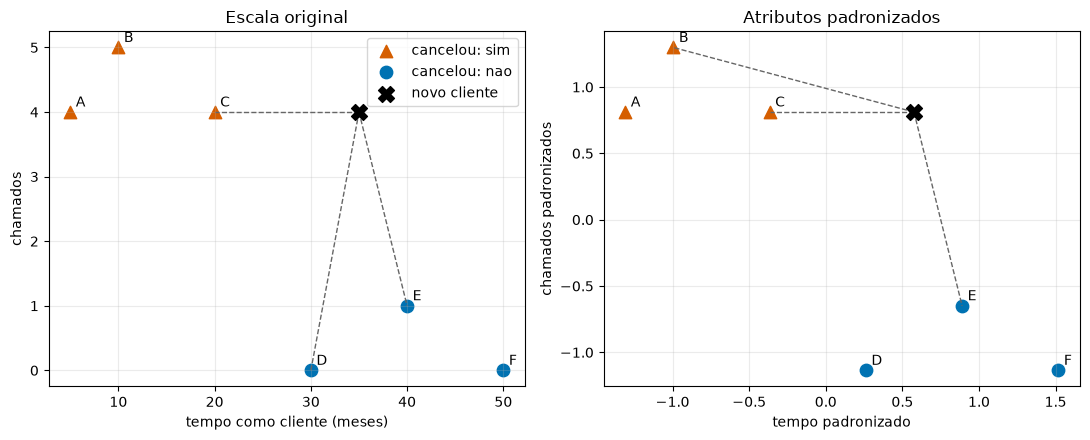

In [3]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.5))

configuracoes = [
    (
        eixos[0],
        X_clientes.to_numpy(),
        novo_cliente.to_numpy()[0],
        vizinhos_original.index,
        "Escala original",
        "tempo como cliente (meses)",
        "chamados",
    ),
    (
        eixos[1],
        X_padronizado,
        novo_padronizado[0],
        vizinhos_padronizados.index,
        "Atributos padronizados",
        "tempo padronizado",
        "chamados padronizados",
    ),
]

for eixo, pontos, consulta, indices, titulo, rotulo_x, rotulo_y in configuracoes:
    for classe, marcador, cor in [
        ("sim", "^", "#D55E00"),
        ("nao", "o", "#0072B2"),
    ]:
        mascara = clientes_treino["cancelou"].eq(classe).to_numpy()
        eixo.scatter(
            pontos[mascara, 0],
            pontos[mascara, 1],
            marker=marcador,
            color=cor,
            s=80,
            label=f"cancelou: {classe}",
        )

    eixo.scatter(
        consulta[0],
        consulta[1],
        marker="X",
        color="#000000",
        s=130,
        label="novo cliente",
        zorder=4,
    )

    for indice in indices:
        eixo.plot(
            [consulta[0], pontos[indice, 0]],
            [consulta[1], pontos[indice, 1]],
            "--",
            color="#666666",
            linewidth=1,
        )

    for indice, identificador in enumerate(clientes_treino["cliente"]):
        eixo.annotate(
            identificador,
            (pontos[indice, 0], pontos[indice, 1]),
            xytext=(4, 4),
            textcoords="offset points",
        )

    eixo.set(title=titulo, xlabel=rotulo_x, ylabel=rotulo_y)
    eixo.grid(alpha=0.25)

eixos[0].legend()
plt.tight_layout()
plt.show()

### O que mudou?

Na escala original, os vizinhos mais próximos são determinados principalmente pelo tempo como cliente. Depois da padronização, diferenças em tempo e chamados passam a ser medidas em unidades comparáveis.

A transformação muda os três vizinhos e pode mudar a votação. Isso não significa que padronizar seja sempre suficiente: atribuir o mesmo peso aos atributos também é uma escolha. Conhecimento do domínio pode indicar que um deles deve pesar mais, que outra distância é apropriada ou que um atributo não deveria ser usado.

## 3. O papel de $k$

- **$k$ pequeno:** decisão muito local; acompanha fronteiras detalhadas, mas é sensível a ruído e casos atípicos.
- **$k$ maior:** votação mais estável; suaviza irregularidades, mas pode apagar grupos pequenos.
- **$k$ grande demais:** aproxima a decisão da classe majoritária da base.

A escolha não deve usar o conjunto de teste final. Em uma análise completa, ela é feita com uma partição de validação ou validação cruzada dentro dos dados de treino. Aqui, observaremos apenas como a previsão do mesmo objeto pode mudar.

In [4]:
resultados_k = []

for representacao, X_usado, consulta in [
    ("original", X_clientes.to_numpy(), novo_cliente.to_numpy()),
    ("padronizada", X_padronizado, novo_padronizado),
]:
    for k in [1, 3, 5]:
        modelo_knn = KNeighborsClassifier(n_neighbors=k)
        modelo_knn.fit(X_usado, clientes_treino["cancelou"])
        resultados_k.append({
            "representacao": representacao,
            "k": k,
            "previsao": modelo_knn.predict(consulta)[0],
        })

pd.DataFrame(resultados_k)

,representacao,k,previsao
0,original,1,nao
1,original,3,nao
2,original,5,nao
3,padronizada,1,sim
4,padronizada,3,sim
5,padronizada,5,sim


## 4. Como $k$ controla sobreajuste e subajuste

Para enxergar o efeito de $k$, usaremos duas regiões curvas com ruído. Os dados serão separados em **ajuste** e **validação**. A validação simula dados não usados para memorizar os vizinhos.

- **$k=1$:** cada objeto de ajuste controla uma pequena região; a fronteira acompanha até irregularidades e ruídos.
- **$k$ intermediário:** vários vizinhos precisam concordar; pequenas irregularidades são suavizadas.
- **$k$ muito grande:** objetos distantes participam da votação; a fronteira pode ficar simples demais e ignorar padrões locais.

Os termos descrevem dois erros diferentes:

| Situação | Comportamento | Indício no desempenho |
|---|---|---|
| **Sobreajuste (*overfitting*)** | memoriza particularidades do ajuste | desempenho de ajuste muito superior ao de validação |
| **Subajuste (*underfitting*)** | modelo simples demais para o padrão | desempenho baixo até nos dados de ajuste |

Esses diagnósticos dependem simultaneamente de $k$, quantidade de dados, ruído, atributos, escala e distância.

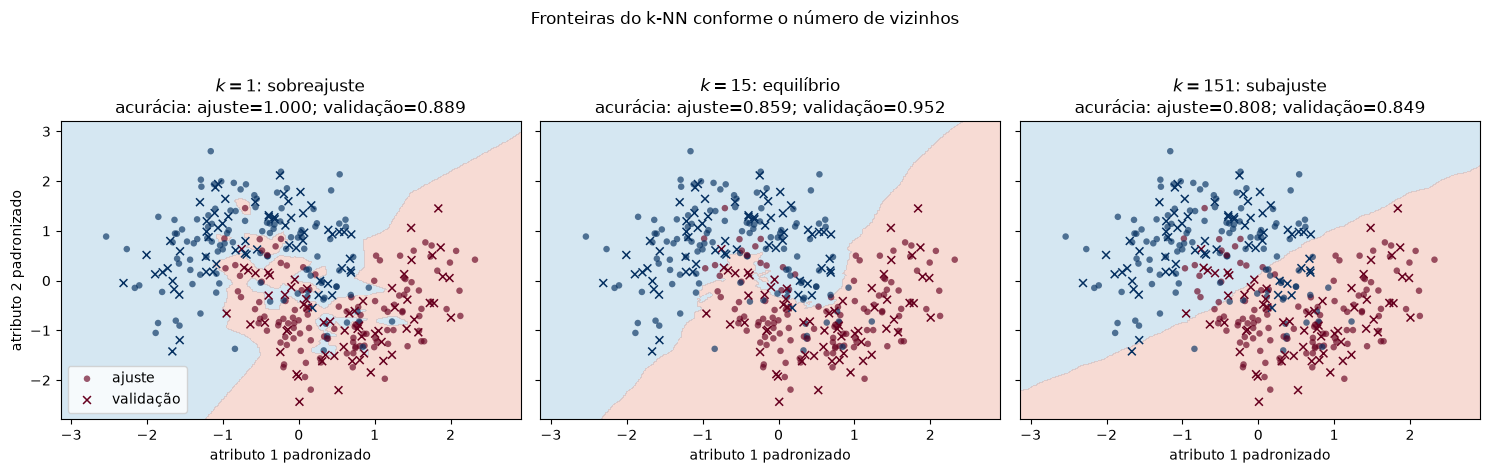

In [5]:
X_sintetico, y_sintetico = make_moons(
    n_samples=360,
    noise=0.30,
    random_state=21,
)
X_ajuste, X_validacao, y_ajuste, y_validacao = train_test_split(
    X_sintetico,
    y_sintetico,
    test_size=0.35,
    stratify=y_sintetico,
    random_state=RANDOM_STATE,
)

escalonador_sintetico = StandardScaler()
X_ajuste_pad = escalonador_sintetico.fit_transform(X_ajuste)
X_validacao_pad = escalonador_sintetico.transform(X_validacao)

x_min, x_max = X_ajuste_pad[:, 0].min() - 0.6, X_ajuste_pad[:, 0].max() + 0.6
y_min, y_max = X_ajuste_pad[:, 1].min() - 0.6, X_ajuste_pad[:, 1].max() + 0.6
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 280),
    np.linspace(y_min, y_max, 280),
)
grade = np.c_[xx.ravel(), yy.ravel()]

configuracoes_k = [
    (1, "$k=1$: sobreajuste"),
    (15, "$k=15$: equilíbrio"),
    (151, "$k=151$: subajuste"),
]

fig, eixos = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)

for eixo, (k, titulo) in zip(eixos, configuracoes_k):
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_ajuste_pad, y_ajuste)

    fronteira = modelo.predict(grade).reshape(xx.shape)
    acuracia_ajuste = accuracy_score(y_ajuste, modelo.predict(X_ajuste_pad))
    acuracia_validacao = accuracy_score(
        y_validacao,
        modelo.predict(X_validacao_pad),
    )

    eixo.contourf(
        xx,
        yy,
        fronteira,
        levels=[-0.5, 0.5, 1.5],
        cmap="RdBu_r",
        alpha=0.28,
    )
    eixo.scatter(
        X_ajuste_pad[:, 0],
        X_ajuste_pad[:, 1],
        c=y_ajuste,
        cmap="RdBu_r",
        s=22,
        alpha=0.65,
        edgecolor="none",
        label="ajuste",
    )
    eixo.scatter(
        X_validacao_pad[:, 0],
        X_validacao_pad[:, 1],
        c=y_validacao,
        cmap="RdBu_r",
        marker="x",
        s=32,
        linewidth=1.1,
        label="validação",
    )
    eixo.set_title(
        f"{titulo}\n"
        f"acurácia: ajuste={acuracia_ajuste:.3f}; "
        f"validação={acuracia_validacao:.3f}"
    )
    eixo.set_xlabel("atributo 1 padronizado")

eixos[0].set_ylabel("atributo 2 padronizado")
eixos[0].legend(loc="lower left")
fig.suptitle("Fronteiras do k-NN conforme o número de vizinhos", y=1.04)
plt.tight_layout()
plt.show()

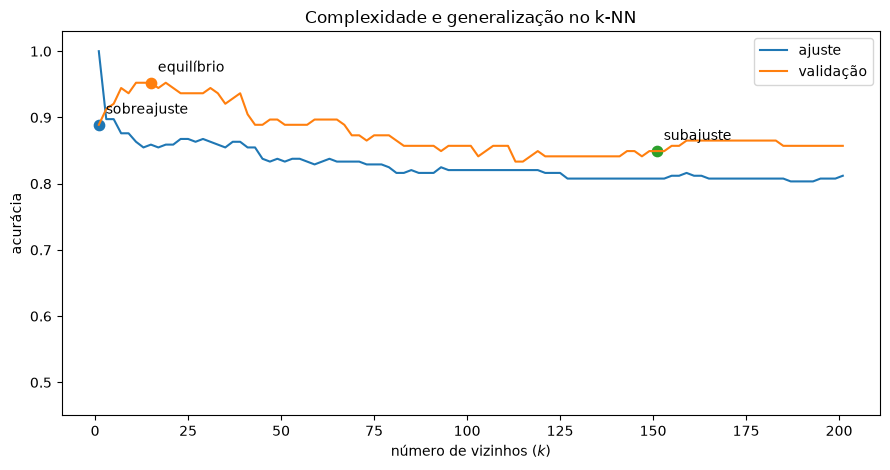

In [6]:
valores_k = list(range(1, 202, 2))
desempenho_k = []

for k in valores_k:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_ajuste_pad, y_ajuste)
    desempenho_k.append({
        "k": k,
        "acurácia_ajuste": accuracy_score(
            y_ajuste,
            modelo.predict(X_ajuste_pad),
        ),
        "acurácia_validação": accuracy_score(
            y_validacao,
            modelo.predict(X_validacao_pad),
        ),
    })

desempenho_k = pd.DataFrame(desempenho_k)

plt.figure(figsize=(9, 4.8))
plt.plot(
    desempenho_k["k"],
    desempenho_k["acurácia_ajuste"],
    label="ajuste",
)
plt.plot(
    desempenho_k["k"],
    desempenho_k["acurácia_validação"],
    label="validação",
)
for k, rotulo in [(1, "sobreajuste"), (15, "equilíbrio"), (151, "subajuste")]:
    linha = desempenho_k.loc[desempenho_k["k"] == k].iloc[0]
    plt.scatter(k, linha["acurácia_validação"], s=55)
    plt.annotate(
        rotulo,
        (k, linha["acurácia_validação"]),
        xytext=(5, 8),
        textcoords="offset points",
    )

plt.xlabel("número de vizinhos ($k$)")
plt.ylabel("acurácia")
plt.title("Complexidade e generalização no k-NN")
plt.ylim(0.45, 1.03)
plt.legend()
plt.tight_layout()
plt.show()

### Como ler as duas ilustrações

No painel com $k=1$, a acurácia de ajuste chega a 1, pois cada observação encontra a si mesma como vizinha. A fronteira apresenta pequenas ilhas e recortes para acomodar exemplos isolados. A queda na validação evidencia que parte desse detalhe não se generaliza: é o padrão típico de **sobreajuste**.

Com $k=15$, a fronteira preserva as duas regiões curvas, mas ignora parte das irregularidades locais. A validação melhora neste exemplo, indicando um compromisso mais adequado entre detalhe e estabilidade.

Com $k=151$, a votação inclui grande parte do conjunto. A fronteira fica excessivamente suave e a acurácia de ajuste também cai: o modelo já não representa adequadamente nem o padrão observado, caracterizando **subajuste**.

A curva reforça que aumentar $k$ reduz a complexidade do k-NN. O melhor intervalo deve ser escolhido por validação dentro do treino. Os valores 1, 15 e 151 foram escolhidos para tornar os comportamentos visíveis neste conjunto; não são recomendações universais.

## 5. Quando considerar k-NN

O k-NN é útil quando semelhança local é defensável e casos próximos ajudam a justificar a decisão. Ele armazena o treino e realiza boa parte do trabalho ao prever.

A escolha exige documentar atributos, transformações, distância e $k$. Em bases grandes ou com muitas dimensões, a busca pode ser cara e as distâncias pouco informativas. Atributos irrelevantes também podem distorcer a vizinhança.

## Atividades

> **U05-NB02-V01 — Verifique seu entendimento:** por que um atributo com amplitude muito maior pode dominar a distância Euclidiana? Explique por que padronizar ajuda, mas não decide se os atributos deveriam ter a mesma importância.

> **U05-NB02-E01 — Exercício:** identifique os três vizinhos do novo cliente antes e depois da padronização e a classe prevista em cada representação. Explique numericamente por que a vizinhança mudou.

> **U05-NB02-E02 — Exercício:** usando a tabela para $k=1,3,5$, descreva como representação e $k$ alteram a previsão. Explique como escolher $k$ sem consultar repetidamente o teste final.

> **U05-NB02-E03 — Decisão de método:** uma equipe quer justificar uma classificação apresentando casos históricos semelhantes. Avalie quando k-NN seria apropriado e indique limitações de escala, dimensionalidade, custo e qualidade da distância.

## Síntese

- O k-NN classifica por votação entre exemplos próximos.
- Proximidade depende de atributos, escala e métrica.
- $k$ pequeno pode sobreajustar; $k$ excessivamente grande pode subajustar.
- Curvas de ajuste e validação ajudam a avaliar generalização.
- Padronização evita domínio numérico, mas não define relevância.
- Escolhas devem ocorrer dentro do treino.

## Referências

- HAN, J.; PEI, J.; TONG, H. *Data Mining: Concepts and Techniques*. 4. ed. 2023. Seção 6.4.
- SCIKIT-LEARN DEVELOPERS. *User Guide: nearest neighbors*.